# Latent Diffusion Results

Load a trained latent diffusion checkpoint, decode its predicted target latent through the target VAE, and compare the result against a standard pixel-space diffusion checkpoint like the one used in notebook 01. Set the run paths in the next cell before executing the notebook.

In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "diffusionsr").exists():
            return path
    raise RuntimeError("Could not find LPBFDiffusionSR project root")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from diffusionsr.datasets.dataset import SimulationXZDataset
from diffusionsr.models.diffusion_model import Unet
from diffusionsr.models.lr_encoder_model import rrdbnet_encoder
from diffusionsr.runners.train_diffusion import forwardpass
from diffusionsr.runners.train_latentdiff import (
    ConditionalLatentDenoiser,
    DirectLatentPredictor,
    FrozenVAEEncoder,
    extract,
    make_beta_schedule,
    normalize_sampler_name,
    resolve_checkpoint,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
PROJECT_ROOT, DEVICE


/project/community/sboseban/miniforge3/envs/lpbfdiffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/home/sboseban/code/LPBFDiffusionSR_dev'), device(type='cuda'))

## Choose Runs

`LATENT_DIFF_RUN_DIR` should be a run directory produced by `runners/train_latentdiff.py`. For the baseline, use the `diffusion_results_dir` and `encoder_results_dir` values from notebook 01, or leave `BASELINE_DIFFUSION_RUN_DIR = None` to only show the latent diffusion result.

In [3]:
# Latent diffusion run. Usually under diffusionsr/runs/direct/latentdiff_diffusion/<timestamp>/standardize/n_steps_1
LATENT_DIFF_RUN_DIR = PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "latentdiff_diffusion" / "2026_05_18_17_05_07" / "standardize" / "n_steps_1"
LATENT_CHECKPOINT_NAME = "best_model.pth"  # or "ckpt.pth"
#LATENT_DIFF_RUN_DIR = "/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/latentdiff_diffusion/2026_05_18_17_05_07/standardize/n_steps_1"
LATENT_DIFF_RUN_DIR = "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/latentdiff_diffusion/2026_06_15_10_28_14/standardize/n_steps_1"
# Optional overrides. Leave as None to use the paths saved in the latent diffusion checkpoint.
LATENT_INPUT_ENCODER_CHECKPOINT = None
LATENT_TARGET_ENCODER_CHECKPOINT = None

# Sampling controls for the latent diffusion checkpoint. None means use checkpoint/config values.
LATENT_SAMPLER = None          # "DDPM" or "DDIM"
LATENT_SAMPLE_TIMESTEPS = None # e.g. 50 for fast DDIM previews
LATENT_DDIM_ETA = None         # 0.0 is deterministic DDIM

# Normal diffusion baseline from notebook 01. Set both paths to compare.
BASELINE_DIFFUSION_RUN_DIR = None#"/home/shohom-tfc/src/LPBFDiffusionSR/diffusionsr/runs/direct/diffusionimplicitencoded/2026_04_22_22_48_29"  # e.g. PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "diffusionimplicitencoded" / "..."
BASELINE_ENCODER_RUN_DIR = None    # e.g. PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "encoder" / "..."
BASELINE_CHECKPOINT_NAME = "ckpt.pth"

# Baseline sampler/config overrides. None means read configuration.yml when available.
BASELINE_SAMPLER = "DDIM"          # "DDPM" or "DDIM"
BASELINE_SAMPLE_TIMESTEPS = 50      # DDIM can be much smaller than BASELINE_TIMESTEPS
BASELINE_DDIM_ETA = 0.0
BASELINE_TIMESTEPS = None
BASELINE_SCHEDULE = None
BASELINE_CONDITIONING = None
BASELINE_ENCODING = None
BASELINE_ENCODER_OUTPUT = None
BASELINE_OUTPUT_TYPE = None         # "hr" for current train_diffusion.py, "residual" for older residual checkpoints

DATA_SPLIT = "test"
BATCH_SIZE = 100
BATCH_INDEX = 8
SAMPLE_INDEX = 99
CHANNEL_INDEX = 0
DEPTH_INDEX = None  # None uses the center depth slice for 3D latent/VAE outputs
RANDOM_SEED = 0
EXPORT_COMPARISON = False

LATENT_DIFF_RUN_DIR


'/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/latentdiff_diffusion/2026_06_15_10_28_14/standardize/n_steps_1'

## Shared Helpers

In [4]:
TARGET_INDEX = {"residual": 0, "hr": 1, "high_resolution": 1, "lr": 2, "true_lr": 2, "upscaled_lr": 3}


def resolve_path(path_like, *, must_exist=True):
    if path_like in [None, ""]:
        return None
    path = Path(path_like).expanduser()
    candidates = [path, PROJECT_ROOT / path, PROJECT_ROOT / "diffusionsr" / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    if must_exist:
        raise FileNotFoundError(f"Could not resolve path: {path_like}. Checked: {candidates}")
    return candidates[0].resolve()


def load_yaml(path):
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, "r") as f:
        return yaml.safe_load(f) or {}


def config_to_field_names(config_dict):
    fields = config_dict.get("fields")
    if fields == "temperature":
        return ["temperature"]
    if fields == "temperature_liqlabel":
        return ["temperature", "liqlabel"]
    if fields == "all_but_pressure":
        return ["vx", "temperature", "vy", "vz", "liqlabel"]
    if fields in ["all", None]:
        return None
    if isinstance(fields, (list, tuple)):
        return list(fields)
    raise ValueError(f"Unsupported fields config: {fields}")


def resolve_root_folder(config_dict):
    root_folder = Path(config_dict["root_folder"]).expanduser()
    if root_folder.is_absolute():
        return str(root_folder)
    candidates = [PROJECT_ROOT / root_folder, PROJECT_ROOT / "diffusionsr" / root_folder]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate.resolve())
    return str(candidates[0].resolve())


def build_dataset(config_dict, split, spatial_dims):
    inflate_dim = config_dict.get("inflate_dim") if spatial_dims == 3 else None
    return SimulationXZDataset(
        downscale_method=config_dict["downscale_method"],
        normalize=config_dict["normalize_method"],
        split=split,
        root_folder=resolve_root_folder(config_dict),
        n_steps=int(config_dict.get("n_steps", 1)),
        field_names=config_to_field_names(config_dict),
        out_steps=config_dict.get("out_steps"),
        inflate_dim=inflate_dim,
        inflate_method=config_dict.get("inflate_method", "repeat"),
    )


def get_batch(loader, batch_index):
    for idx, batch in enumerate(loader):
        if idx == batch_index:
            return batch
    raise IndexError(f"Batch index {batch_index} is outside loader length {len(loader)}")


def canonical_data_type(data_type):
    aliases = {"high_resolution": "hr", "true_lr": "lr"}
    return aliases.get(data_type, data_type)


def format_tensor(tensor, spatial_dims, depth_size=1):
    if spatial_dims == 2:
        if tensor.ndim == 3:
            return tensor.unsqueeze(1)
        if tensor.ndim != 4:
            raise ValueError(f"Expected 4D 2D batch, got {tuple(tensor.shape)}")
        return tensor
    if tensor.ndim == 5:
        return tensor
    if tensor.ndim != 4:
        raise ValueError(f"Expected flattened 3D tensor or 5D tensor, got {tuple(tensor.shape)}")
    batch_size, channels, height, width = tensor.shape
    if channels % depth_size != 0:
        raise ValueError(f"Channel count {channels} is not divisible by depth_size={depth_size}")
    return tensor.reshape(batch_size, channels // depth_size, depth_size, height, width)


def select_tensor(batch, data_type, spatial_dims, depth_size=1):
    tensor = batch[TARGET_INDEX[data_type]]
    return format_tensor(tensor, spatial_dims, depth_size=depth_size).to(DEVICE).float()


def _select_stats(dataset, data_type):
    data_type = canonical_data_type(data_type)
    if data_type == "hr":
        return np.asarray(dataset.mean_hr), np.asarray(dataset.std_hr)
    if data_type == "lr":
        return np.asarray(dataset.mean_lr), np.asarray(dataset.std_lr)
    if data_type == "upscaled_lr":
        return np.asarray(dataset.mean_upscaled_lr), np.asarray(dataset.std_upscaled_lr)
    if data_type == "residual":
        return np.asarray(dataset.mean_resid), np.asarray(dataset.std_resid)
    raise ValueError(f"Unsupported data_type: {data_type}")


def unscale_volume(dataset, volume, data_type):
    data_type = canonical_data_type(data_type)
    volume = np.asarray(volume)
    channels, depth, height, width = volume.shape
    flat = volume.reshape(channels * depth, height, width)

    if getattr(dataset, "normalize", None) == "rescaling":
        unscaled = np.asarray(dataset.unscale_data(flat, input_type=data_type))
        return unscaled.reshape(channels, depth, height, width)

    mean, std = _select_stats(dataset, data_type)
    if mean.ndim == 2:
        mean = np.broadcast_to(mean, (channels * depth, height, width))
        std = np.broadcast_to(std, (channels * depth, height, width))
        return (flat * std + mean).reshape(channels, depth, height, width)
    if mean.ndim == 3:
        unscaled = np.asarray(dataset.unscale_data(flat, input_type=data_type))
        return unscaled.reshape(channels, depth, height, width)
    if mean.ndim == 4:
        return volume * std + mean
    raise ValueError(f"Unexpected stats rank for {data_type}: {mean.ndim}")


def unscale_batch(dataset, tensor, data_type):
    data_type = canonical_data_type(data_type)
    array = tensor.detach().cpu().numpy() if torch.is_tensor(tensor) else np.asarray(tensor)
    if array.ndim == 5:
        return np.stack([unscale_volume(dataset, sample, data_type) for sample in array], axis=0)
    return np.asarray(dataset.unscale_data(array, input_type=data_type))


def as_numpy(array):
    return array.detach().cpu().numpy() if torch.is_tensor(array) else np.asarray(array)


def infer_spatial_dims(array):
    return 3 if as_numpy(array).ndim == 5 else 2


def display_slice(array, sample_index=0, channel_index=0, depth_index=None, spatial_dims=2):
    values = as_numpy(array)
    sample_index = max(0, min(values.shape[0] - 1, int(sample_index)))
    channel_index = max(0, min(values.shape[1] - 1, int(channel_index)))
    image = values[sample_index, channel_index]
    if spatial_dims == 3:
        depth = image.shape[0]
        idx = depth // 2 if depth_index is None else int(depth_index)
        idx = max(0, min(depth - 1, idx))
        return image[idx], idx, sample_index, channel_index
    return image, None, sample_index, channel_index


def display_settings(dataset, data_type, channel_index):
    field_names = getattr(dataset, "field_names", []) or []
    field_name = field_names[channel_index % len(field_names)] if field_names else "field"
    if canonical_data_type(data_type) != "residual" and field_name == "temperature":
        return "jet", 298.0, 5000.0, field_name
    if field_name == "liqlabel":
        return "gray", 0.0, 1.0, field_name
    return "viridis", None, None, field_name


def mae_rmse(prediction, target):
    pred = as_numpy(prediction).astype(float)
    targ = as_numpy(target).astype(float)
    diff = pred - targ
    return {
        "mae": float(np.mean(np.abs(diff))),
        "rmse": float(np.sqrt(np.mean(diff ** 2))),
        "max_abs_error": float(np.max(np.abs(diff))),
    }


## Load Latent Diffusion

In [5]:
latent_run_dir = resolve_path(LATENT_DIFF_RUN_DIR)
latent_checkpoint_path = latent_run_dir / LATENT_CHECKPOINT_NAME
latent_config_path = latent_run_dir / "configuration.yml"
assert latent_checkpoint_path.exists(), f"Missing latent checkpoint: {latent_checkpoint_path}"
assert latent_config_path.exists(), f"Missing latent copied config: {latent_config_path}"

latent_checkpoint = torch.load(latent_checkpoint_path, map_location=DEVICE)
latent_config = load_yaml(latent_config_path)
latent_model_config = latent_checkpoint["model_config"]
latent_trainer_config = latent_checkpoint.get("trainer_config", {})
latent_mode = latent_trainer_config.get("mode", "diffusion")
spatial_dims = int(latent_trainer_config.get("spatial_dims", latent_model_config.get("spatial_dims", 2)))
depth_size = int(latent_trainer_config.get("depth_size") or latent_config.get("inflate_dim") or 1)

input_encoder_path = LATENT_INPUT_ENCODER_CHECKPOINT or latent_trainer_config.get("input_encoder_checkpoint")
target_encoder_path = LATENT_TARGET_ENCODER_CHECKPOINT or latent_trainer_config.get("target_encoder_checkpoint")
input_encoder = FrozenVAEEncoder(resolve_checkpoint(input_encoder_path), device=DEVICE)
target_encoder = FrozenVAEEncoder(resolve_checkpoint(target_encoder_path), device=DEVICE)

if latent_model_config["model_type"] == "latent_diffusion_denoiser":
    latent_model = ConditionalLatentDenoiser(
        spatial_dims=int(latent_model_config["spatial_dims"]),
        latent_channels=int(latent_model_config["latent_channels"]),
        condition_channels=int(latent_model_config["condition_channels"]),
        hidden_channels=int(latent_model_config["hidden_channels"]),
        num_blocks=int(latent_model_config["num_blocks"]),
    )
elif latent_model_config["model_type"] == "direct_latent_predictor":
    latent_model = DirectLatentPredictor(
        spatial_dims=int(latent_model_config["spatial_dims"]),
        input_channels=int(latent_model_config["input_channels"]),
        output_channels=int(latent_model_config["output_channels"]),
        hidden_channels=int(latent_model_config["hidden_channels"]),
        num_blocks=int(latent_model_config["num_blocks"]),
    )
else:
    raise ValueError(f"Unsupported latent model type: {latent_model_config['model_type']}")

latent_model.load_state_dict(latent_checkpoint["model_state_dict"])
latent_model.to(DEVICE).eval()
for param in latent_model.parameters():
    param.requires_grad = False

latent_sampler = normalize_sampler_name(LATENT_SAMPLER or latent_trainer_config.get("sampler", "DDPM"))
latent_timesteps = int(latent_trainer_config.get("timesteps", latent_config.get("latent_timesteps", 200)))
latent_sample_timesteps = int(LATENT_SAMPLE_TIMESTEPS or latent_trainer_config.get("sample_timesteps", latent_timesteps))
latent_sample_timesteps = min(latent_sample_timesteps, latent_timesteps)
latent_ddim_eta = float(LATENT_DDIM_ETA if LATENT_DDIM_ETA is not None else latent_trainer_config.get("ddim_eta", 0.0))
latent_schedule = latent_trainer_config.get("schedule", latent_config.get("latent_schedule", "linear"))
latent_input_type = latent_trainer_config.get("input_type", latent_config.get("latent_input_type", "lr"))
latent_target_type = latent_trainer_config.get("target_type", latent_config.get("latent_target_type", "hr"))

print(json.dumps({
    "latent_checkpoint": str(latent_checkpoint_path),
    "saved_at": latent_checkpoint.get("saved_at"),
    "mode": latent_mode,
    "input_type": latent_input_type,
    "target_type": latent_target_type,
    "sampler": latent_sampler,
    "timesteps": latent_timesteps,
    "sample_timesteps": latent_sample_timesteps,
    "ddim_eta": latent_ddim_eta,
    "input_encoder": str(input_encoder.checkpoint_path),
    "target_encoder": str(target_encoder.checkpoint_path),
}, indent=2, default=str))


{
  "latent_checkpoint": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/latentdiff_diffusion/2026_06_15_10_28_14/standardize/n_steps_1/best_model.pth",
  "saved_at": "2026-06-15T16:57:07",
  "mode": "diffusion",
  "input_type": "upscaled_lr",
  "target_type": "hr",
  "sampler": "DDIM",
  "timesteps": 1000,
  "sample_timesteps": 100,
  "ddim_eta": 0.0,
  "input_encoder": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_14_19_10_12/standardize/n_steps_1/best_model.pth",
  "target_encoder": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_12_13_55_01/standardize/n_steps_1/best_model.pth"
}


## Rebuild Dataset And Select Sample

In [6]:
dataset = build_dataset(latent_config, DATA_SPLIT, spatial_dims)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
batch = get_batch(loader, BATCH_INDEX)

residual = select_tensor(batch, "residual", spatial_dims, depth_size=depth_size)
hr = select_tensor(batch, "hr", spatial_dims, depth_size=depth_size)
true_lr = select_tensor(batch, "lr", spatial_dims, depth_size=depth_size)
upscaled_lr = select_tensor(batch, "upscaled_lr", spatial_dims, depth_size=depth_size)

model_input = select_tensor(batch, latent_input_type, spatial_dims, depth_size=depth_size)
target = select_tensor(batch, latent_target_type, spatial_dims, depth_size=depth_size)

hr_unscaled = unscale_batch(dataset, hr, "hr")
true_lr_unscaled = unscale_batch(dataset, true_lr, "lr")
upscaled_lr_unscaled = unscale_batch(dataset, upscaled_lr, "upscaled_lr")
target_unscaled = unscale_batch(dataset, target, latent_target_type)

print({
    "dataset_len": len(dataset),
    "batch_shapes": {
        "hr": tuple(hr.shape),
        "true_lr": tuple(true_lr.shape),
        "upscaled_lr": tuple(upscaled_lr.shape),
        "latent_input": tuple(model_input.shape),
        "latent_target": tuple(target.shape),
    },
    "field_names": getattr(dataset, "field_names", None),
})


ValueError: Unsupported fields config: temperature_liqlabel_meltregion

## Sample Latent Diffusion And Decode Through Target VAE

In [ ]:
def sample_timestep_indices(total_timesteps, sample_timesteps, device):
    total_timesteps = int(total_timesteps)
    sample_timesteps = max(1, min(int(sample_timesteps), total_timesteps))
    if total_timesteps > 1 and sample_timesteps < 2:
        raise ValueError("sample_timesteps must be at least 2 when timesteps > 1")
    if sample_timesteps == 1:
        return torch.tensor([total_timesteps - 1], device=device, dtype=torch.long)
    return torch.linspace(0, total_timesteps - 1, steps=sample_timesteps, device=device).round().long().unique()


def predict_x0_from_noise(noisy_latent, timestep, predicted_noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod):
    sqrt_alpha = extract(sqrt_alphas_cumprod, timestep, noisy_latent.shape)
    sqrt_one_minus = extract(sqrt_one_minus_alphas_cumprod, timestep, noisy_latent.shape)
    return (noisy_latent - sqrt_one_minus * predicted_noise) / sqrt_alpha.clamp_min(1e-12)


def sample_latent_denoiser(model, condition_latent, latent_shape, sampler, timesteps, sample_timesteps, schedule, ddim_eta=0.0):
    sampler = normalize_sampler_name(sampler)
    betas = make_beta_schedule(schedule, timesteps).to(DEVICE)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    posterior_variance = (betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)).clamp_min(1e-20)

    shape = (condition_latent.shape[0], int(latent_model_config["latent_channels"]), *tuple(latent_shape))
    latent = torch.randn(shape, device=DEVICE)
    indices = sample_timestep_indices(timesteps, sample_timesteps, DEVICE).tolist()

    if sampler == "DDPM":
        for time_index in reversed(indices):
            timestep = torch.full((shape[0],), int(time_index), device=DEVICE, dtype=torch.long)
            predicted_noise = model(latent, timestep, condition_latent)
            beta = extract(betas, timestep, latent.shape)
            sqrt_one_minus = extract(sqrt_one_minus_alphas_cumprod, timestep, latent.shape)
            sqrt_recip_alpha = extract(sqrt_recip_alphas, timestep, latent.shape)
            model_mean = sqrt_recip_alpha * (latent - beta * predicted_noise / sqrt_one_minus.clamp_min(1e-12))
            if time_index == 0:
                latent = model_mean
            else:
                variance = extract(posterior_variance, timestep, latent.shape)
                latent = model_mean + torch.sqrt(variance) * torch.randn_like(latent)
        return latent

    for position in reversed(range(len(indices))):
        time_index = int(indices[position])
        next_index = int(indices[position - 1]) if position > 0 else -1
        timestep = torch.full((shape[0],), time_index, device=DEVICE, dtype=torch.long)
        predicted_noise = model(latent, timestep, condition_latent)
        alpha = extract(alphas_cumprod, timestep, latent.shape)
        predicted_x0 = predict_x0_from_noise(latent, timestep, predicted_noise, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod)
        if next_index < 0:
            latent = predicted_x0
            continue
        next_timestep = torch.full((shape[0],), next_index, device=DEVICE, dtype=torch.long)
        alpha_next = extract(alphas_cumprod, next_timestep, latent.shape)
        sigma = float(ddim_eta) * torch.sqrt(
            ((1.0 - alpha_next) / (1.0 - alpha)).clamp_min(0.0)
            * (1.0 - alpha / alpha_next).clamp_min(0.0)
        )
        direction = torch.sqrt((1.0 - alpha_next - sigma.square()).clamp_min(0.0)) * predicted_noise
        latent = torch.sqrt(alpha_next) * predicted_x0 + direction
        if float(ddim_eta) > 0:
            latent = latent + sigma * torch.randn_like(latent)
    return latent


torch.manual_seed(RANDOM_SEED)
condition_latent = input_encoder.encode(model_input, sample_posterior=False)
target_latent = target_encoder.encode(target, sample_posterior=False)

if latent_mode == "nn":
    predicted_latent = latent_model(condition_latent, output_shape=target_latent.shape[-spatial_dims:])
else:
    predicted_latent = sample_latent_denoiser(
        latent_model,
        condition_latent,
        target_latent.shape[-spatial_dims:],
        sampler=latent_sampler,
        timesteps=latent_timesteps,
        sample_timesteps=latent_sample_timesteps,
        schedule=latent_schedule,
        ddim_eta=latent_ddim_eta,
    )

latent_reconstruction = target_encoder.model.decode(predicted_latent, output_shape=target.shape[-spatial_dims:])
latent_prediction_unscaled = unscale_batch(dataset, latent_reconstruction, latent_target_type)

if canonical_data_type(latent_target_type) == "residual":
    latent_prediction_display = latent_prediction_unscaled + upscaled_lr_unscaled
    comparison_target = hr_unscaled
else:
    latent_prediction_display = latent_prediction_unscaled
    comparison_target = hr_unscaled if canonical_data_type(latent_target_type) == "hr" else target_unscaled

print({
    "condition_latent_shape": tuple(condition_latent.shape),
    "target_latent_shape": tuple(target_latent.shape),
    "predicted_latent_shape": tuple(predicted_latent.shape),
    "decoded_shape": tuple(latent_reconstruction.shape),
})


{'condition_latent_shape': (100, 8, 4, 4), 'target_latent_shape': (100, 8, 8, 8), 'predicted_latent_shape': (100, 8, 8, 8), 'decoded_shape': (100, 1, 60, 60)}


## Optional Normal Diffusion Baseline

The old baseline path expects a pixel-space diffusion checkpoint plus its RRDB encoder checkpoint. If the model was trained to emit residuals, set `BASELINE_OUTPUT_TYPE = "residual"`; if it was trained by the current `train_diffusion.py` path, keep `"hr"` or leave it unset when `residual_flag: false` is in the copied config.

In [ ]:
def remove_module_prefix(state_dict):
    return {key.split("module.")[-1] if key.startswith("module.") else key: value for key, value in state_dict.items()}


def baseline_beta_schedule(schedule, timesteps):
    schedule = str(schedule).lower()
    if schedule == "linear":
        return torch.linspace(0.0001, 0.02, int(timesteps))
    if schedule == "quadratic":
        return torch.linspace(0.0001 ** 0.5, 0.02 ** 0.5, int(timesteps)) ** 2
    if schedule == "sigmoid":
        values = torch.linspace(-6, 6, int(timesteps))
        return torch.sigmoid(values) * (0.02 - 0.0001) + 0.0001
    if schedule == "cosine":
        steps = int(timesteps) + 1
        x = torch.linspace(0, int(timesteps), steps)
        alphas_cumprod = torch.cos(((x / int(timesteps)) + 0.008) / 1.008 * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        return torch.clip(1 - (alphas_cumprod[1:] / alphas_cumprod[:-1]), 0.0001, 0.9999)
    raise ValueError(f"Unsupported baseline schedule: {schedule}")


def load_baseline_encoder(encoder_run_dir, dataset, out_steps=None):
    encoder_run_dir = resolve_path(encoder_run_dir)
    checkpoint_path = encoder_run_dir / "model_saved.pth"
    assert checkpoint_path.exists(), f"Missing baseline encoder checkpoint: {checkpoint_path}"
    out_steps = int(out_steps or getattr(dataset, "out_steps", dataset.n_steps))
    encoder = rrdbnet_encoder(
        upscale_factor=dataset.factor,
        in_channels=dataset.n_steps * dataset.num_fields,
        out_channels=out_steps * dataset.num_fields,
    ).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    encoder.load_state_dict(checkpoint["model_state_dict"])
    encoder.eval()
    for param in encoder.parameters():
        param.requires_grad = False
    return encoder


def load_baseline_diffusion_model(run_dir, checkpoint_name, dataset, baseline_config):
    run_dir = resolve_path(run_dir)
    checkpoint_path = run_dir / checkpoint_name
    assert checkpoint_path.exists(), f"Missing baseline diffusion checkpoint: {checkpoint_path}"

    timesteps = int(BASELINE_TIMESTEPS or baseline_config.get("timesteps", 1000))
    schedule = BASELINE_SCHEDULE or baseline_config.get("schedule", "linear")
    conditioning = BASELINE_CONDITIONING or baseline_config.get("conditioning", "implicit")
    encoding = bool(BASELINE_ENCODING if BASELINE_ENCODING is not None else baseline_config.get("encoding", True))
    enc_output = bool(BASELINE_ENCODER_OUTPUT if BASELINE_ENCODER_OUTPUT is not None else baseline_config.get("enc_output", False))
    out_steps = baseline_config.get("out_steps") or getattr(dataset, "out_steps", dataset.n_steps)
    channels = int(out_steps) * dataset.num_fields
    init_dim = channels if enc_output else None

    model = Unet(
        dim=dataset.img_shape,
        channels=channels,
        init_dim=init_dim,
        dim_mults=(1, 2, 4),
        conditioning=conditioning,
        out_dim=channels,
        encoder_flag=encoding,
    ).to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    state_dict = checkpoint[0] if isinstance(checkpoint, (list, tuple)) else checkpoint.get("model_state_dict", checkpoint)
    try:
        model.load_state_dict(state_dict)
    except RuntimeError:
        model.load_state_dict(remove_module_prefix(state_dict))
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    return model, {
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_path,
        "timesteps": timesteps,
        "schedule": schedule,
        "conditioning": conditioning,
        "encoding": encoding,
        "enc_output": enc_output,
        "out_steps": out_steps,
        "channels": channels,
    }


def encode_baseline_condition(encoder, lr_tensor, upscaled_lr_tensor, dataset, encoding=True, enc_output=False):
    if encoding:
        return forwardpass(
            encoder,
            lr_tensor.to(DEVICE).float(),
            factor=dataset.factor,
            output=enc_output,
            transform_rescale=False,
            dataset=dataset,
        )
    return upscaled_lr_tensor.to(DEVICE).float()


def sample_baseline_diffusion(model, condition, shape, sampler, timesteps, sample_timesteps, schedule, eta=0.0):
    sampler = normalize_sampler_name(sampler)
    betas = baseline_beta_schedule(schedule, timesteps).to(DEVICE)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_one_minus = torch.sqrt(1.0 - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    posterior_variance = (betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)).clamp_min(1e-20)
    indices = sample_timestep_indices(timesteps, sample_timesteps or timesteps, DEVICE).tolist()
    sample = torch.randn(shape, device=DEVICE)

    if sampler == "DDPM":
        for time_index in reversed(indices):
            timestep = torch.full((shape[0],), int(time_index), device=DEVICE, dtype=torch.long)
            predicted_noise = model(sample, timestep, condition)
            beta = extract(betas, timestep, sample.shape)
            sqrt_om = extract(sqrt_one_minus, timestep, sample.shape)
            sqrt_recip_alpha = extract(sqrt_recip_alphas, timestep, sample.shape)
            model_mean = sqrt_recip_alpha * (sample - beta * predicted_noise / sqrt_om.clamp_min(1e-12))
            if time_index == 0:
                sample = model_mean
            else:
                variance = extract(posterior_variance, timestep, sample.shape)
                sample = model_mean + torch.sqrt(variance) * torch.randn_like(sample)
        return sample

    for position in reversed(range(len(indices))):
        time_index = int(indices[position])
        next_index = int(indices[position - 1]) if position > 0 else -1
        timestep = torch.full((shape[0],), time_index, device=DEVICE, dtype=torch.long)
        predicted_noise = model(sample, timestep, condition)
        alpha = extract(alphas_cumprod, timestep, sample.shape)
        predicted_x0 = (sample - predicted_noise * torch.sqrt(1.0 - alpha)) / torch.sqrt(alpha).clamp_min(1e-12)
        if next_index < 0:
            sample = predicted_x0
            continue
        next_timestep = torch.full((shape[0],), next_index, device=DEVICE, dtype=torch.long)
        alpha_next = extract(alphas_cumprod, next_timestep, sample.shape)
        sigma = float(eta) * torch.sqrt(
            ((1.0 - alpha_next) / (1.0 - alpha)).clamp_min(0.0)
            * (1.0 - alpha / alpha_next).clamp_min(0.0)
        )
        direction = torch.sqrt((1.0 - alpha_next - sigma.square()).clamp_min(0.0)) * predicted_noise
        sample = torch.sqrt(alpha_next) * predicted_x0 + direction
        if float(eta) > 0:
            sample = sample + sigma * torch.randn_like(sample)
    return sample


baseline_prediction_display = None
baseline_info = None
if BASELINE_DIFFUSION_RUN_DIR is None:
    print("BASELINE_DIFFUSION_RUN_DIR is None; skipping normal diffusion comparison.")
else:
    if spatial_dims != 2:
        raise NotImplementedError("The notebook 01 normal-diffusion baseline is 2D-only. Leave BASELINE_DIFFUSION_RUN_DIR=None for 3D latent runs.")
    baseline_run_dir = resolve_path(BASELINE_DIFFUSION_RUN_DIR)
    baseline_config = load_yaml(baseline_run_dir / "configuration.yml")
    baseline_model, baseline_info = load_baseline_diffusion_model(
        baseline_run_dir,
        BASELINE_CHECKPOINT_NAME,
        dataset,
        baseline_config,
    )
    baseline_encoder = None
    if baseline_info["encoding"]:
        encoder_dir = BASELINE_ENCODER_RUN_DIR or baseline_config.get("encoder_results_dir")
        assert encoder_dir not in [None, ""], "Set BASELINE_ENCODER_RUN_DIR for encoded baseline diffusion checkpoints."
        baseline_encoder = load_baseline_encoder(encoder_dir, dataset, out_steps=baseline_info["out_steps"])

    baseline_sampler = normalize_sampler_name(BASELINE_SAMPLER or baseline_config.get("sampler", "DDPM"))
    baseline_sample_timesteps = int(BASELINE_SAMPLE_TIMESTEPS or baseline_info["timesteps"])
    baseline_output_type = BASELINE_OUTPUT_TYPE
    if baseline_output_type is None:
        baseline_output_type = "residual" if bool(baseline_config.get("residual_flag", False)) else "hr"

    torch.manual_seed(RANDOM_SEED)
    baseline_condition = encode_baseline_condition(
        baseline_encoder,
        true_lr,
        upscaled_lr,
        dataset,
        encoding=baseline_info["encoding"],
        enc_output=baseline_info["enc_output"],
    )
    baseline_scaled = sample_baseline_diffusion(
        baseline_model,
        baseline_condition,
        tuple(hr.shape),
        sampler=baseline_sampler,
        timesteps=baseline_info["timesteps"],
        sample_timesteps=baseline_sample_timesteps,
        schedule=baseline_info["schedule"],
        eta=BASELINE_DDIM_ETA,
    )
    baseline_unscaled = unscale_batch(dataset, baseline_scaled, baseline_output_type)
    baseline_prediction_display = baseline_unscaled + upscaled_lr_unscaled if baseline_output_type == "residual" else baseline_unscaled
    baseline_info.update({
        "sampler": baseline_sampler,
        "sample_timesteps": baseline_sample_timesteps,
        "ddim_eta": BASELINE_DDIM_ETA,
        "output_type": baseline_output_type,
        "encoder_dir": str(BASELINE_ENCODER_RUN_DIR or baseline_config.get("encoder_results_dir")),
    })
    print(json.dumps({key: str(value) for key, value in baseline_info.items()}, indent=2))


BASELINE_DIFFUSION_RUN_DIR is None; skipping normal diffusion comparison.


## Comparison View

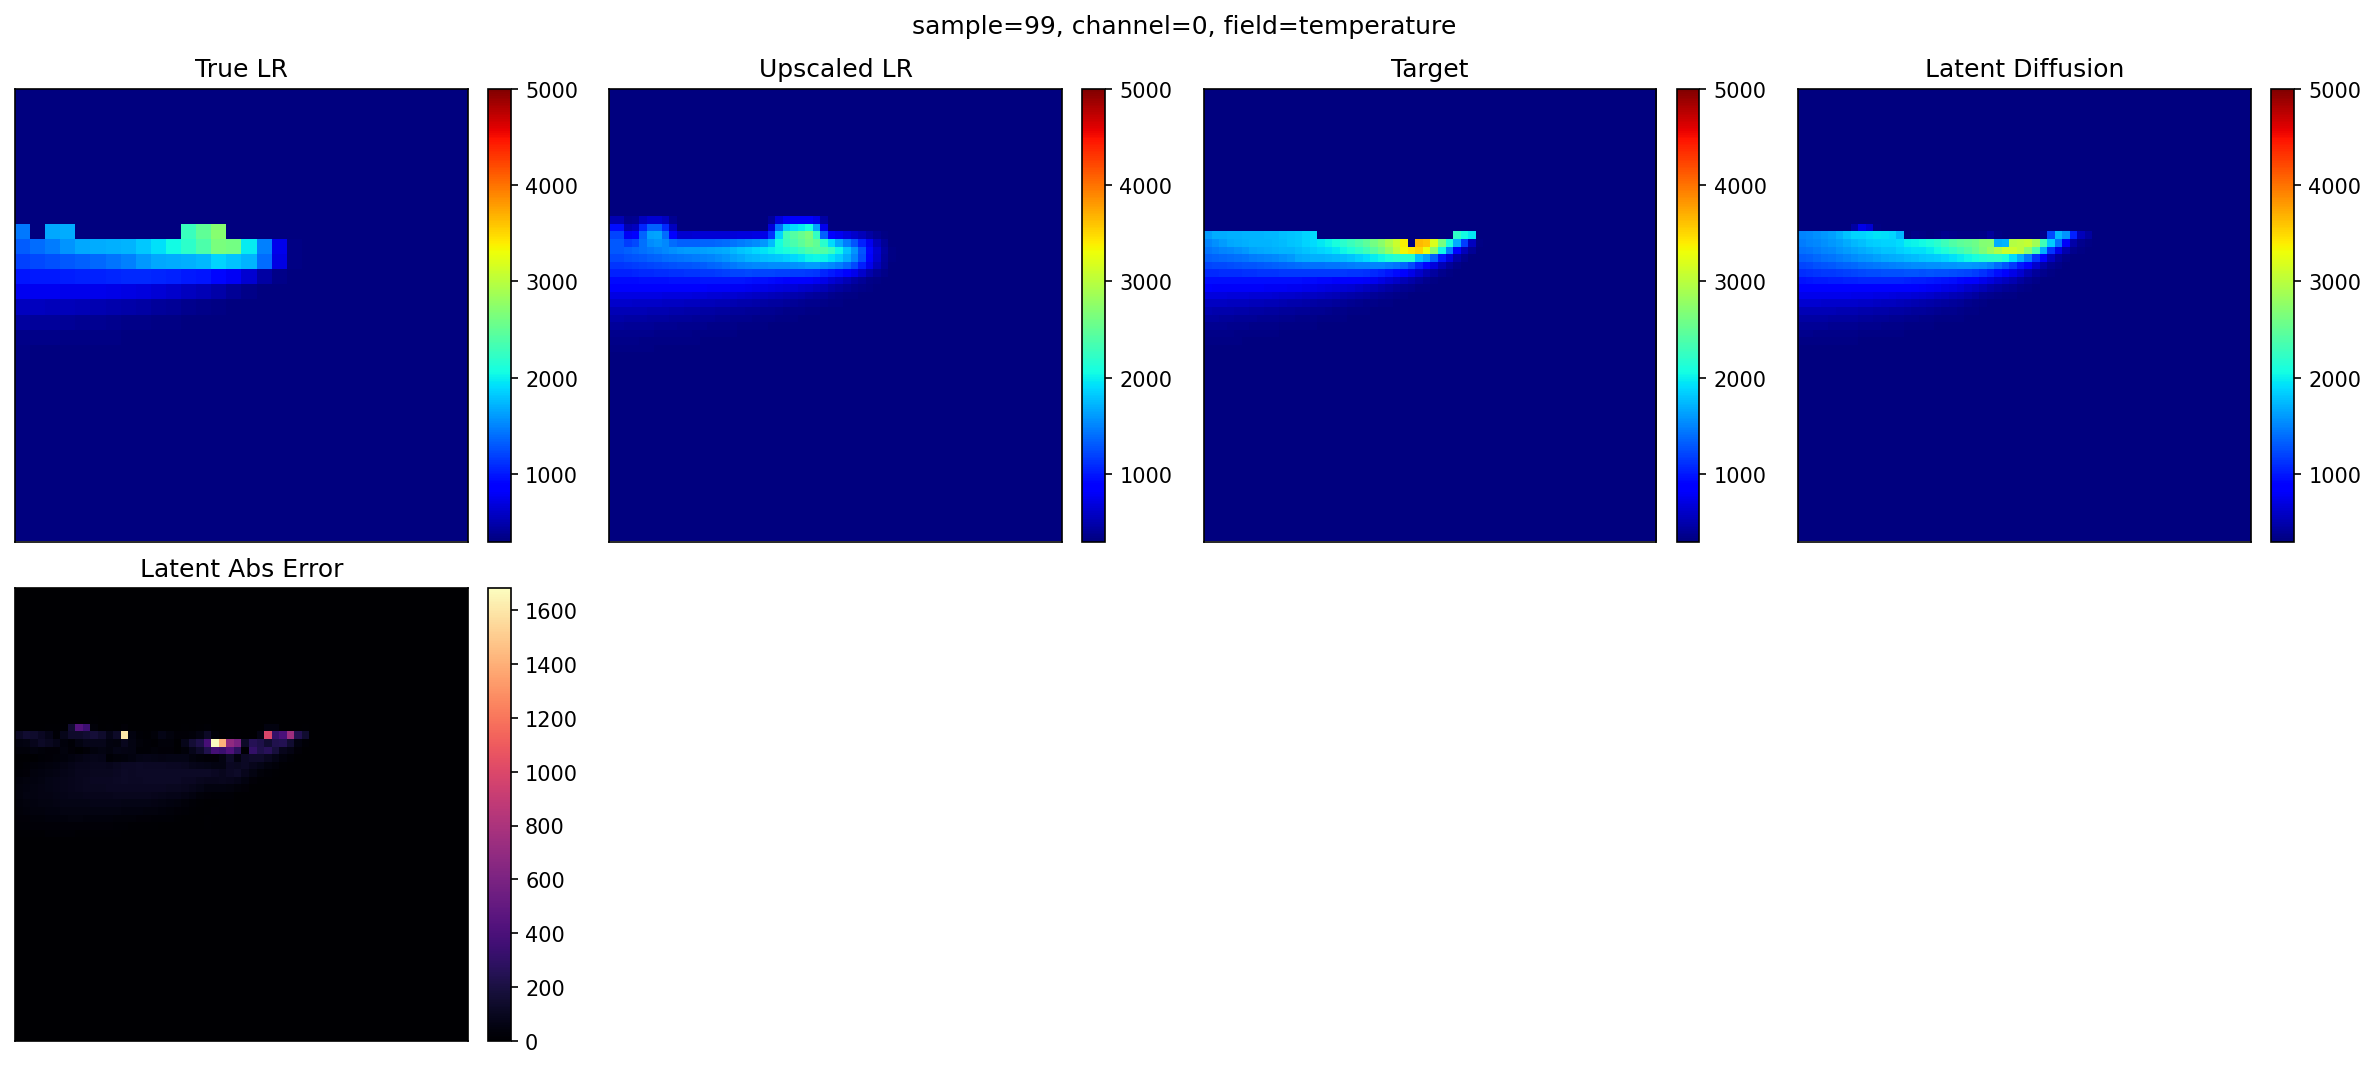

In [ ]:
cmap, vmin, vmax, field_name = display_settings(dataset, "hr", CHANNEL_INDEX)

panels = [
    ("True LR", true_lr_unscaled, "lr", cmap, vmin, vmax),
    ("Upscaled LR", upscaled_lr_unscaled, "upscaled_lr", cmap, vmin, vmax),
    ("Target", comparison_target, "hr", cmap, vmin, vmax),
    ("Latent Diffusion", latent_prediction_display, "hr", cmap, vmin, vmax),
]
if baseline_prediction_display is not None:
    panels.append(("Normal Diffusion", baseline_prediction_display, "hr", cmap, vmin, vmax))

latent_error = np.abs(as_numpy(latent_prediction_display) - as_numpy(comparison_target))
panels.append(("Latent Abs Error", latent_error, "error", "magma", None, None))
if baseline_prediction_display is not None:
    baseline_error = np.abs(as_numpy(baseline_prediction_display) - as_numpy(comparison_target))
    panels.append(("Normal Abs Error", baseline_error, "error", "magma", None, None))

ncols = min(4, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.6 * nrows), dpi=150)
axes = np.asarray(axes).reshape(-1)

for ax, (title, data, data_type, panel_cmap, panel_vmin, panel_vmax) in zip(axes, panels):
    panel_spatial_dims = infer_spatial_dims(data)
    image, depth_idx, sample_idx, channel_idx = display_slice(
        data,
        sample_index=SAMPLE_INDEX,
        channel_index=CHANNEL_INDEX,
        depth_index=DEPTH_INDEX,
        spatial_dims=panel_spatial_dims,
    )
    im = ax.imshow(image.T, origin="lower", cmap=panel_cmap, vmin=panel_vmin, vmax=panel_vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(panels):]:
    ax.axis("off")

subtitle = f"sample={SAMPLE_INDEX}, channel={CHANNEL_INDEX}, field={field_name}"
if spatial_dims == 3:
    subtitle += f", depth={DEPTH_INDEX if DEPTH_INDEX is not None else 'center'}"
fig.suptitle(subtitle)
fig.tight_layout()
plt.show()


In [ ]:
#cell to compare across multiple samples


## Metrics

In [ ]:
rows = []
latent_metrics = mae_rmse(latent_prediction_display, comparison_target)
rows.append({"model": "latent_diffusion", **latent_metrics})
if baseline_prediction_display is not None:
    rows.append({"model": "normal_diffusion", **mae_rmse(baseline_prediction_display, comparison_target)})

try:
    import pandas as pd
    metrics_df = pd.DataFrame(rows)
    display(metrics_df)
except Exception:
    print(json.dumps(rows, indent=2))


[
  {
    "model": "latent_diffusion",
    "mae": 12.864484205747797,
    "rmse": 99.44596209784035,
    "max_abs_error": 3637.3352815644507
  }
]


## Test-Set Statistics

Compute the same style of whole-test-set statistics as the final cell of notebook 05: MAE, melt/keyhole profile errors, voxel/classification MAE, per-sample Wasserstein distance, global Wasserstein distance, percentile summaries, and top-error samples. This runs latent diffusion for every selected test batch, and also evaluates the normal diffusion baseline when it has been configured above.


In [ ]:
from scipy.stats import wasserstein_distance
from diffusionsr.analysis.analysis_functions import get_profile

ANALYSIS_SPLIT = "test"
ANALYSIS_BATCH_SIZE = 16  # Increase until you hit GPU memory limits.
ANALYSIS_MAX_TEST_BATCHES = None  # Limits loader batches. None processes the full split.
ANALYSIS_METRIC_CHANNEL = CHANNEL_INDEX
ANALYSIS_MELT_THRESHOLD = 800.0
ANALYSIS_INCLUDE_BASELINE = baseline_info is not None
ANALYSIS_EXPORT_CSV = False

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


def build_analysis_dataset(config_dict, split, spatial_dims):
    inflate_dim = config_dict.get("inflate_dim") if spatial_dims == 3 else None
    return SimulationXZDataset(
        downscale_method=config_dict["downscale_method"],
        normalize=config_dict["normalize_method"],
        split=split,
        root_folder=resolve_root_folder(config_dict),
        n_steps=int(config_dict.get("n_steps", 1)),
        field_names=config_to_field_names(config_dict),
        out_steps=config_dict.get("out_steps"),
        inflate_dim=inflate_dim,
        inflate_method=config_dict.get("inflate_method", "repeat"),
        return_info=True,
    )


def analysis_melt_pool_profile(slice_2d, threshold=800.0):
    image = np.asarray(slice_2d).T
    binarized = image > threshold
    profile = []
    keyhole_profile = []
    max_idx = binarized.shape[1]
    for column_idx in range(binarized.shape[1]):
        coords = np.where(binarized[:, column_idx])[0]
        if len(coords) > 0:
            profile.append(int(np.min(coords)))
            keyhole_profile.append(int(np.max(coords)))
        else:
            profile.append(max_idx)
            keyhole_profile.append(max_idx)
    return np.asarray(profile), np.asarray(keyhole_profile)


def ensure_depth_volume(sample_or_volume):
    array = np.asarray(sample_or_volume)
    if array.ndim == 3:  # C, H, W
        return array[:, None, :, :]
    if array.ndim == 4:  # C, D, H, W
        return array
    raise ValueError(f"Expected sample with shape (C,H,W) or (C,D,H,W), got {array.shape}")


def extract_profile_temperatures_from_sample(sample_or_volume, channel_idx=0):
    volume = ensure_depth_volume(sample_or_volume)
    scalar_volume = np.asarray(volume[channel_idx])
    collected_values = []

    for depth_idx in range(scalar_volume.shape[0]):
        slice_2d = np.asarray(scalar_volume[depth_idx])
        image = slice_2d.T
        _, keyhole_profile = get_profile(slice_2d[None, ...], max_idx=image.shape[0])

        for column_idx, row_idx in enumerate(keyhole_profile.astype(int)):
            if row_idx < image.shape[0]:
                collected_values.append(float(image[row_idx, column_idx]))

    return np.asarray(collected_values, dtype=np.float64)


def compute_sample_metrics(pred_sample_unscaled, target_sample_unscaled, metric_channel=0, melt_threshold=800.0):
    pred_volume = ensure_depth_volume(pred_sample_unscaled)
    target_volume = ensure_depth_volume(target_sample_unscaled)
    pred_scalar = np.asarray(pred_volume[metric_channel])
    target_scalar = np.asarray(target_volume[metric_channel])

    mae = float(np.mean(np.abs(pred_scalar - target_scalar)))

    profile_errors = []
    keyhole_errors = []
    for depth_idx in range(pred_scalar.shape[0]):
        pred_profile, pred_keyhole = analysis_melt_pool_profile(pred_scalar[depth_idx], threshold=melt_threshold)
        target_profile, target_keyhole = analysis_melt_pool_profile(target_scalar[depth_idx], threshold=melt_threshold)
        profile_errors.append(np.mean(np.abs(pred_profile - target_profile)))
        keyhole_errors.append(np.mean(np.abs(pred_keyhole - target_keyhole)))

    mp_mae = float(np.mean(profile_errors))
    kp_mae = float(np.mean(keyhole_errors))

    pred_mask = pred_scalar >= melt_threshold
    target_mask = target_scalar >= melt_threshold
    vc_mae = float(np.mean(np.abs(pred_mask.astype(np.float32) - target_mask.astype(np.float32))))

    pred_distribution_values = extract_profile_temperatures_from_sample(
        pred_volume,
        channel_idx=metric_channel,
    )
    target_distribution_values = extract_profile_temperatures_from_sample(
        target_volume,
        channel_idx=metric_channel,
    )

    wasserstein_shift = float("nan")
    if pred_distribution_values.size > 0 and target_distribution_values.size > 0:
        wasserstein_shift = float(
            wasserstein_distance(target_distribution_values, pred_distribution_values)
        )

    return {
        "MAE": mae,
        "MP_MAE": mp_mae,
        "KP_MAE": kp_mae,
        "VC_MAE": vc_mae,
        "WASSERSTEIN": wasserstein_shift,
        "pred_occupied_voxels": int(pred_mask.sum()),
        "target_occupied_voxels": int(target_mask.sum()),
        "pred_profile_temp_count": int(pred_distribution_values.size),
        "target_profile_temp_count": int(target_distribution_values.size),
        "pred_min": float(pred_scalar.min()),
        "pred_max": float(pred_scalar.max()),
        "target_min": float(target_scalar.min()),
        "target_max": float(target_scalar.max()),
        "pred_distribution_values": pred_distribution_values,
        "target_distribution_values": target_distribution_values,
    }


def append_metrics_for_batch(
    rows,
    distribution_store,
    model_name,
    pred_batch_unscaled,
    target_batch_unscaled,
    info_batch,
    loader_batch_idx,
    batch_size,
):
    pred_batch = np.asarray(pred_batch_unscaled)
    target_batch = np.asarray(target_batch_unscaled)
    for sample_offset in range(pred_batch.shape[0]):
        sample_idx = loader_batch_idx * batch_size + sample_offset
        metrics = compute_sample_metrics(
            pred_sample_unscaled=pred_batch[sample_offset],
            target_sample_unscaled=target_batch[sample_offset],
            metric_channel=ANALYSIS_METRIC_CHANNEL,
            melt_threshold=ANALYSIS_MELT_THRESHOLD,
        )
        pred_distribution_values = metrics.pop("pred_distribution_values")
        target_distribution_values = metrics.pop("target_distribution_values")

        if pred_distribution_values.size > 0:
            distribution_store[model_name]["pred"].append(pred_distribution_values)
        if target_distribution_values.size > 0:
            distribution_store[model_name]["target"].append(target_distribution_values)

        metadata = info_batch[sample_offset]
        metrics.update({
            "model": model_name,
            "sample_idx": sample_idx,
            "loader_batch_idx": loader_batch_idx,
            "power": float(metadata[0]) if len(metadata) > 0 else float("nan"),
            "velocity": float(metadata[1]) if len(metadata) > 1 else float("nan"),
            "time": float(metadata[2]) if len(metadata) > 2 else float("nan"),
        })
        rows.append(metrics)


def summarize_metric_rows(rows, distribution_store, model_name, num_loader_batches):
    model_rows = [row for row in rows if row["model"] == model_name]
    if not model_rows:
        return None, []

    mae_values = np.asarray([row["MAE"] for row in model_rows], dtype=np.float64)
    wasserstein_values = np.asarray(
        [row["WASSERSTEIN"] for row in model_rows if np.isfinite(row["WASSERSTEIN"])],
        dtype=np.float64,
    )
    sorted_mae_values = np.sort(mae_values)
    top_k = min(10, len(model_rows))
    top_mae_rows = sorted(model_rows, key=lambda row: row["MAE"], reverse=True)[:top_k]
    top_1pct_count = max(1, int(np.ceil(0.01 * len(sorted_mae_values))))
    trimmed_mae_values = sorted_mae_values[:-top_1pct_count] if len(sorted_mae_values) > top_1pct_count else sorted_mae_values
    median_mae = float(np.median(mae_values))
    suspicious_factor = 10.0
    suspicious_count = int(np.sum(mae_values > suspicious_factor * median_mae)) if median_mae > 0 else 0

    global_pred_distribution_values = (
        np.concatenate(distribution_store[model_name]["pred"])
        if distribution_store[model_name]["pred"]
        else np.asarray([], dtype=np.float64)
    )
    global_target_distribution_values = (
        np.concatenate(distribution_store[model_name]["target"])
        if distribution_store[model_name]["target"]
        else np.asarray([], dtype=np.float64)
    )
    global_wasserstein = float("nan")
    if global_pred_distribution_values.size > 0 and global_target_distribution_values.size > 0:
        global_wasserstein = float(
            wasserstein_distance(global_target_distribution_values, global_pred_distribution_values)
        )

    summary = {
        "model": model_name,
        "num_loader_batches": num_loader_batches,
        "num_samples": len(model_rows),
        "analysis_split": ANALYSIS_SPLIT,
        "analysis_metric_channel": ANALYSIS_METRIC_CHANNEL,
        "analysis_melt_threshold": ANALYSIS_MELT_THRESHOLD,
        "analysis_batch_size": ANALYSIS_BATCH_SIZE,
    }

    if model_name == "latent_diffusion":
        summary.update({
            "analysis_sampler": latent_sampler if latent_mode != "nn" else "nn",
            "analysis_timesteps": latent_timesteps if latent_mode != "nn" else 0,
            "analysis_sample_timesteps": latent_sample_timesteps if latent_mode != "nn" else 0,
            "analysis_ddim_eta": latent_ddim_eta if latent_mode != "nn" else 0.0,
        })
    elif baseline_info is not None:
        summary.update({
            "analysis_sampler": baseline_info.get("sampler"),
            "analysis_timesteps": baseline_info.get("timesteps"),
            "analysis_sample_timesteps": baseline_info.get("sample_timesteps"),
            "analysis_ddim_eta": baseline_info.get("ddim_eta"),
        })

    for metric_name in [
        "MAE",
        "MP_MAE",
        "KP_MAE",
        "VC_MAE",
        "pred_occupied_voxels",
        "target_occupied_voxels",
        "pred_profile_temp_count",
        "target_profile_temp_count",
    ]:
        summary[metric_name] = float(np.mean([row[metric_name] for row in model_rows]))

    if wasserstein_values.size > 0:
        summary["WASSERSTEIN_mean"] = float(np.mean(wasserstein_values))
        summary["WASSERSTEIN_median"] = float(np.median(wasserstein_values))
        summary["WASSERSTEIN_p95"] = float(np.percentile(wasserstein_values, 95))
        summary["WASSERSTEIN_max"] = float(np.max(wasserstein_values))
    else:
        summary["WASSERSTEIN_mean"] = float("nan")
        summary["WASSERSTEIN_median"] = float("nan")
        summary["WASSERSTEIN_p95"] = float("nan")
        summary["WASSERSTEIN_max"] = float("nan")

    summary["WASSERSTEIN_global_profile_temperature"] = global_wasserstein
    summary["global_pred_profile_temp_count"] = int(global_pred_distribution_values.size)
    summary["global_target_profile_temp_count"] = int(global_target_distribution_values.size)
    summary["MAE_median"] = median_mae
    summary["MAE_p95"] = float(np.percentile(mae_values, 95))
    summary["MAE_p99"] = float(np.percentile(mae_values, 99))
    summary["MAE_max"] = float(np.max(mae_values))
    summary["MAE_mean_excluding_top_1pct"] = float(np.mean(trimmed_mae_values))
    summary["num_samples_above_10x_median_MAE"] = suspicious_count

    return summary, top_mae_rows


analysis_dataset = build_analysis_dataset(latent_config, ANALYSIS_SPLIT, spatial_dims)
analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=ANALYSIS_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    pin_memory=DEVICE.type == "cuda",
)

all_metric_rows = []
all_distribution_values = {
    "latent_diffusion": {"pred": [], "target": []},
}
if ANALYSIS_INCLUDE_BASELINE:
    if spatial_dims != 2:
        print("Skipping normal diffusion baseline statistics because notebook 01 baseline is 2D-only.")
        ANALYSIS_INCLUDE_BASELINE = False
    else:
        all_distribution_values["normal_diffusion"] = {"pred": [], "target": []}

processed_loader_batches = 0
for loader_batch_idx, batch in enumerate(analysis_loader):
    if ANALYSIS_MAX_TEST_BATCHES is not None and loader_batch_idx >= ANALYSIS_MAX_TEST_BATCHES:
        break

    if len(batch) == 5:
        residual_batch, hr_batch, true_lr_batch, upscaled_lr_batch, info = batch
        info_batch = info.detach().cpu().numpy()
    else:
        residual_batch, hr_batch, true_lr_batch, upscaled_lr_batch = batch
        info_batch = np.full((hr_batch.shape[0], 3), np.nan, dtype=np.float64)

    hr_tensor = select_tensor(batch, "hr", spatial_dims, depth_size=depth_size)
    true_lr_tensor = select_tensor(batch, "lr", spatial_dims, depth_size=depth_size)
    upscaled_lr_tensor = select_tensor(batch, "upscaled_lr", spatial_dims, depth_size=depth_size)
    model_input_tensor = select_tensor(batch, latent_input_type, spatial_dims, depth_size=depth_size)
    target_tensor = select_tensor(batch, latent_target_type, spatial_dims, depth_size=depth_size)

    hr_batch_unscaled = unscale_batch(analysis_dataset, hr_tensor, "hr")
    upscaled_lr_batch_unscaled = unscale_batch(analysis_dataset, upscaled_lr_tensor, "upscaled_lr")
    target_batch_unscaled = unscale_batch(analysis_dataset, target_tensor, latent_target_type)

    torch.manual_seed(RANDOM_SEED + loader_batch_idx)
    condition_latent_batch = input_encoder.encode(model_input_tensor, sample_posterior=False)
    target_latent_batch = target_encoder.encode(target_tensor, sample_posterior=False)
    if latent_mode == "nn":
        predicted_latent_batch = latent_model(condition_latent_batch, output_shape=target_latent_batch.shape[-spatial_dims:])
    else:
        predicted_latent_batch = sample_latent_denoiser(
            latent_model,
            condition_latent_batch,
            target_latent_batch.shape[-spatial_dims:],
            sampler=latent_sampler,
            timesteps=latent_timesteps,
            sample_timesteps=latent_sample_timesteps,
            schedule=latent_schedule,
            ddim_eta=latent_ddim_eta,
        )
    latent_reconstruction_batch = target_encoder.model.decode(
        predicted_latent_batch,
        output_shape=target_tensor.shape[-spatial_dims:],
    )
    latent_prediction_batch_unscaled = unscale_batch(analysis_dataset, latent_reconstruction_batch, latent_target_type)

    if canonical_data_type(latent_target_type) == "residual":
        latent_prediction_for_metrics = latent_prediction_batch_unscaled + upscaled_lr_batch_unscaled
        comparison_target_for_metrics = hr_batch_unscaled
    elif canonical_data_type(latent_target_type) == "hr":
        latent_prediction_for_metrics = latent_prediction_batch_unscaled
        comparison_target_for_metrics = hr_batch_unscaled
    else:
        latent_prediction_for_metrics = latent_prediction_batch_unscaled
        comparison_target_for_metrics = target_batch_unscaled

    append_metrics_for_batch(
        rows=all_metric_rows,
        distribution_store=all_distribution_values,
        model_name="latent_diffusion",
        pred_batch_unscaled=latent_prediction_for_metrics,
        target_batch_unscaled=comparison_target_for_metrics,
        info_batch=info_batch,
        loader_batch_idx=loader_batch_idx,
        batch_size=ANALYSIS_BATCH_SIZE,
    )

    if ANALYSIS_INCLUDE_BASELINE:
        torch.manual_seed(RANDOM_SEED + loader_batch_idx)
        baseline_condition_batch = encode_baseline_condition(
            baseline_encoder,
            true_lr_tensor,
            upscaled_lr_tensor,
            analysis_dataset,
            encoding=baseline_info["encoding"],
            enc_output=baseline_info["enc_output"],
        )
        baseline_scaled_batch = sample_baseline_diffusion(
            baseline_model,
            baseline_condition_batch,
            tuple(hr_tensor.shape),
            sampler=baseline_info["sampler"],
            timesteps=baseline_info["timesteps"],
            sample_timesteps=baseline_info["sample_timesteps"],
            schedule=baseline_info["schedule"],
            eta=baseline_info["ddim_eta"],
        )
        baseline_batch_unscaled = unscale_batch(analysis_dataset, baseline_scaled_batch, baseline_info["output_type"])
        if baseline_info["output_type"] == "residual":
            baseline_prediction_for_metrics = baseline_batch_unscaled + upscaled_lr_batch_unscaled
        else:
            baseline_prediction_for_metrics = baseline_batch_unscaled
        append_metrics_for_batch(
            rows=all_metric_rows,
            distribution_store=all_distribution_values,
            model_name="normal_diffusion",
            pred_batch_unscaled=baseline_prediction_for_metrics,
            target_batch_unscaled=hr_batch_unscaled,
            info_batch=info_batch,
            loader_batch_idx=loader_batch_idx,
            batch_size=ANALYSIS_BATCH_SIZE,
        )

    processed_loader_batches = loader_batch_idx + 1
    print(f"processed batch {processed_loader_batches}/{len(analysis_loader)}", end="\r")

if len(all_metric_rows) == 0:
    raise ValueError("No test samples were processed. Check ANALYSIS_MAX_TEST_BATCHES and ANALYSIS_BATCH_SIZE.")

analysis_summaries = []
analysis_top_rows = {}
for model_name in all_distribution_values:
    summary, top_rows = summarize_metric_rows(
        all_metric_rows,
        all_distribution_values,
        model_name=model_name,
        num_loader_batches=processed_loader_batches,
    )
    if summary is not None:
        analysis_summaries.append(summary)
        analysis_top_rows[model_name] = top_rows

try:
    import pandas as pd

    analysis_summary_df = pd.DataFrame(analysis_summaries)
    analysis_rows_df = pd.DataFrame(all_metric_rows)
    display(analysis_summary_df)
    for model_name, top_rows in analysis_top_rows.items():
        print(f"\nTop samples by MAE: {model_name}")
        display(pd.DataFrame(top_rows)[[
            "model",
            "sample_idx",
            "loader_batch_idx",
            "MAE",
            "WASSERSTEIN",
            "pred_min",
            "pred_max",
            "target_min",
            "target_max",
            "power",
            "velocity",
            "time",
        ]])
except Exception:
    print(json.dumps(analysis_summaries, indent=2))
    for model_name, top_rows in analysis_top_rows.items():
        print(f"\nTop samples by MAE: {model_name}")
        for row in top_rows:
            print({
                "sample_idx": row["sample_idx"],
                "loader_batch_idx": row["loader_batch_idx"],
                "MAE": row["MAE"],
                "WASSERSTEIN": row["WASSERSTEIN"],
                "pred_min": row["pred_min"],
                "pred_max": row["pred_max"],
                "target_min": row["target_min"],
                "target_max": row["target_max"],
                "power": row["power"],
                "velocity": row["velocity"],
                "time": row["time"],
            })

if ANALYSIS_EXPORT_CSV:
    export_prefix = latent_run_dir / f"test_statistics_{ANALYSIS_SPLIT}_{latent_sampler}_{latent_sample_timesteps}steps"
    try:
        analysis_summary_df.to_csv(f"{export_prefix}_summary.csv", index=False)
        analysis_rows_df.to_csv(f"{export_prefix}_samples.csv", index=False)
        print(f"Wrote {export_prefix}_summary.csv and {export_prefix}_samples.csv")
    except NameError:
        print("Install pandas or set ANALYSIS_EXPORT_CSV=False to skip CSV export.")


Using normalize method: ... standardize
Using specific fields, ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
[rocessed batch 277/277
  {
    "model": "latent_diffusion",
    "num_loader_batches": 277,
    "num_samples": 4423,
    "analysis_split": "test",
    "analysis_metric_channel": 0,
    "analysis_melt_threshold": 800.0,
    "analysis_batch_size": 16,
    "analysis_sampler": "DDIM",
    "analysis_timesteps": 400,
    "analysis_sample_timesteps": 50,
    "analysis_ddim_eta": 0.0,
    "MAE": 65.65186523187059,
    "MP_MAE": 1.2736189614891855,
    "KP_MAE": 1.4211696435300325,
    "VC_MAE": 0.02132577187563401,
    "pred_occupied_voxels": 241.5234004069636,
    "target_occupied_voxels": 249.88424146506895,
    "pred_profile_temp_count": 19.947546913859373,
    "target_profile_temp_count": 22.43386841510287,
    "WASSERSTEIN_mean": 542.3950347025253,
    "WASSERSTEIN_median": 516.9087017734189,
    "WASSERSTEIN_p95": 1052.9201090533036,
    "WASSERSTEIN_max": 

## Latent Maps

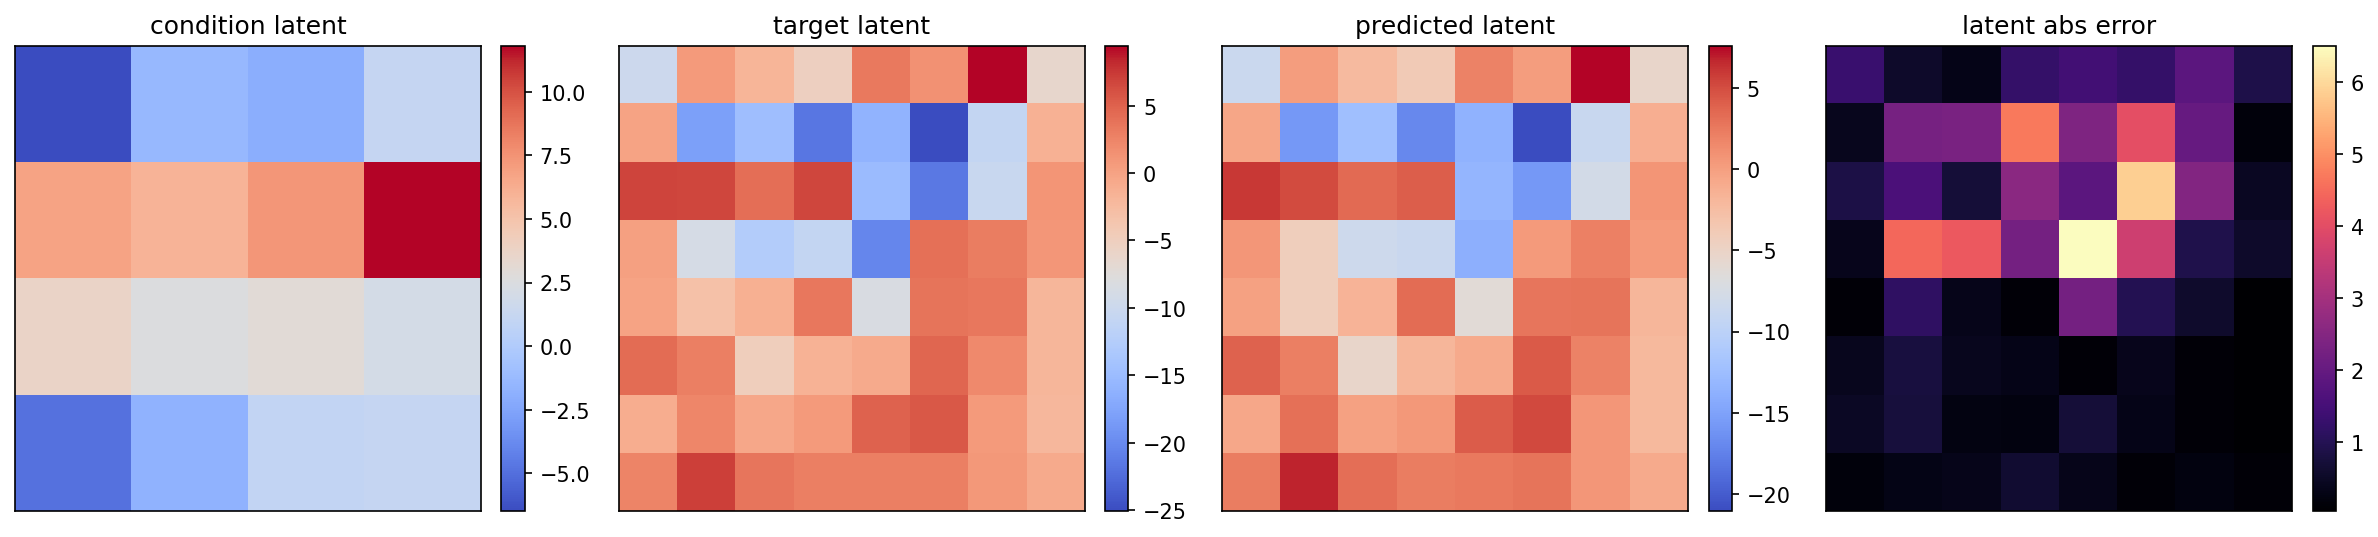

In [ ]:
latent_panels = [
    ("condition latent", condition_latent),
    ("target latent", target_latent),
    ("predicted latent", predicted_latent),
    ("latent abs error", torch.abs(predicted_latent - target_latent)),
]
fig, axes = plt.subplots(1, len(latent_panels), figsize=(4 * len(latent_panels), 3.5), dpi=150)
for ax, (title, data) in zip(np.asarray(axes).reshape(-1), latent_panels):
    image, depth_idx, sample_idx, channel_idx = display_slice(
        data,
        sample_index=SAMPLE_INDEX,
        channel_index=min(CHANNEL_INDEX, data.shape[1] - 1),
        depth_index=DEPTH_INDEX,
        spatial_dims=spatial_dims,
    )
    panel_cmap = "magma" if "error" in title else "coolwarm"
    im = ax.imshow(image.T, origin="lower", cmap=panel_cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


## Training Curves

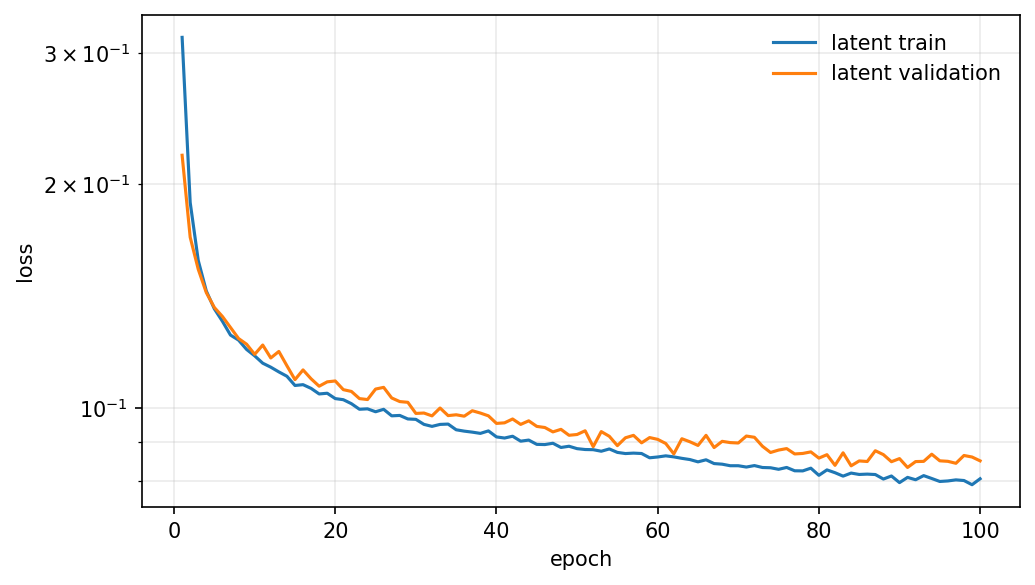

In [ ]:
def read_history(run_dir):
    run_dir = Path(run_dir)
    history_path = run_dir / "history.csv"
    if history_path.exists():
        with open(history_path, "r", newline="") as f:
            rows = list(csv.DictReader(f))
        epochs = [int(float(row.get("epoch", idx + 1))) for idx, row in enumerate(rows)]
        train = [float(row["train/loss"]) for row in rows if "train/loss" in row]
        val = [float(row["validation/loss"]) for row in rows if "validation/loss" in row]
        return epochs, train, val
    train_path = run_dir / "loss_epoch.txt"
    val_path = run_dir / "validation_loss_epoch.txt"
    train = np.loadtxt(train_path).reshape(-1).tolist() if train_path.exists() else []
    val = np.loadtxt(val_path).reshape(-1).tolist() if val_path.exists() else []
    epochs = list(range(1, max(len(train), len(val)) + 1))
    return epochs, train, val


fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
for label, run_dir in [("latent", latent_run_dir), ("normal", resolve_path(BASELINE_DIFFUSION_RUN_DIR) if BASELINE_DIFFUSION_RUN_DIR else None)]:
    if run_dir is None:
        continue
    epochs, train_loss, val_loss = read_history(run_dir)
    if train_loss:
        ax.plot(epochs[:len(train_loss)], train_loss, label=f"{label} train")
    if val_loss:
        ax.plot(epochs[:len(val_loss)], val_loss, label=f"{label} validation")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_yscale("log")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()


## Optional Export

In [ ]:
if EXPORT_COMPARISON:
    export_path = latent_run_dir / f"latent_diff_comparison_{DATA_SPLIT}_batch_{BATCH_INDEX:04d}_sample_{SAMPLE_INDEX:04d}.npz"
    payload = {
        "true_lr": as_numpy(true_lr_unscaled),
        "upscaled_lr": as_numpy(upscaled_lr_unscaled),
        "target": as_numpy(comparison_target),
        "latent_prediction": as_numpy(latent_prediction_display),
        "condition_latent": as_numpy(condition_latent),
        "target_latent": as_numpy(target_latent),
        "predicted_latent": as_numpy(predicted_latent),
        "latent_checkpoint": np.array(str(latent_checkpoint_path)),
    }
    if baseline_prediction_display is not None:
        payload["normal_diffusion_prediction"] = as_numpy(baseline_prediction_display)
    np.savez_compressed(export_path, **payload)
    print(export_path)
else:
    print("Set EXPORT_COMPARISON = True in the run-selection cell to write a compressed comparison export.")


Set EXPORT_COMPARISON = True in the run-selection cell to write a compressed comparison export.
